In [1]:
#分析测试集，得到Homogeneous RL test.ipynb，Unhomogeneous RL test.ipynb，Fluid approximation test.ipynb测试所需的乘客数据
import os
import pandas as pd
import numpy as np

# ======================================================
# 参数设置（只改这里）
# ======================================================

INPUT_FILES = [
    r"C:\Users\lenovo\Desktop\DQN2\data\yellow_tripdata_2025-11.parquet",
]

OUTPUT_FOLDER = "filtered_daily_trips_17_19_core_zones"

CORE_ZONES = [
    237, 161, 236, 186, 162, 230, 142, 239, 163
]

MIN_TRIPS_PER_DAY = 2500   # 👈 乘客数太少的天直接丢弃

# ======================================================
# 主处理逻辑
# ======================================================

def process_and_split_by_day(input_files, core_zones, output_folder):
    os.makedirs(output_folder, exist_ok=True)

    zone_set = set(core_zones)

    daily_groups = {}

    print("🚕 开始处理 TLC 数据")
    print(f"核心区域: {core_zones}")
    print("时间条件: 工作日 + 17:00–19:00")
    print("=" * 80)

    for file_path in input_files:
        print(f"\n📂 读取文件: {file_path}")
        df = pd.read_parquet(file_path)
        print(f"  原始行数: {len(df):,}")

        # =====================
        # 时间戳处理（毫秒）
        # =====================
        if not np.issubdtype(df["tpep_pickup_datetime"].dtype, np.datetime64):
            df["pickup_dt"] = pd.to_datetime(
                df["tpep_pickup_datetime"], unit="ms"
            )
        else:
            df["pickup_dt"] = df["tpep_pickup_datetime"]

        # =====================
        # 工作日
        # =====================
        df = df[df["pickup_dt"].dt.weekday < 5]

        # =====================
        # 17:00–19:00
        # =====================
        h = df["pickup_dt"].dt.hour
        df = df[(h >= 17) & (h < 19)]

        # =====================
        # 起终点都在核心区域
        # =====================
        df = df[
            df["PULocationID"].isin(zone_set) &
            df["DOLocationID"].isin(zone_set)
        ]

        print(f"  筛选后行数: {len(df):,}")

        if df.empty:
            continue

        # =====================
        # 按天聚合
        # =====================
        df["date"] = df["pickup_dt"].dt.date

        for date, group in df.groupby("date"):
            if date not in daily_groups:
                daily_groups[date] = []
            daily_groups[date].append(group)

    print("\n" + "=" * 80)
    print("📊 开始按天筛选 & 保存")
    print("=" * 80)

    kept_days = 0
    dropped_days = 0

    for date, chunks in sorted(daily_groups.items()):
        day_df = pd.concat(chunks, ignore_index=True)
        trip_count = len(day_df)

        if trip_count < MIN_TRIPS_PER_DAY:
            dropped_days += 1
            print(f"❌ {date} 乘客数过少 ({trip_count}) → 丢弃")
            continue

        # 删除辅助列
        day_df = day_df.drop(columns=["date"])

        # 保存
        filename = f"trips_{date}_17_19_core.parquet"
        filepath = os.path.join(output_folder, filename)
        day_df.to_parquet(filepath, index=False)

        kept_days += 1
        print(f"✅ {date} 保存成功 ({trip_count} 条)")

    print("\n" + "=" * 80)
    print("🎯 处理完成")
    print("=" * 80)
    print(f"保留天数: {kept_days}")
    print(f"丢弃天数: {dropped_days}")
    print(f"输出目录: {output_folder}")


# ======================================================
# 运行
# ======================================================

if __name__ == "__main__":
    process_and_split_by_day(
        INPUT_FILES,
        CORE_ZONES,
        OUTPUT_FOLDER
    )


🚕 开始处理 TLC 数据
核心区域: [237, 161, 236, 186, 162, 230, 142, 239, 163]
时间条件: 工作日 + 17:00–19:00

📂 读取文件: C:\Users\lenovo\Desktop\DQN2\data\yellow_tripdata_2025-11.parquet
  原始行数: 4,181,444
  筛选后行数: 58,859

📊 开始按天筛选 & 保存
✅ 2025-11-03 保存成功 (2814 条)
✅ 2025-11-04 保存成功 (2968 条)
✅ 2025-11-05 保存成功 (3236 条)
✅ 2025-11-06 保存成功 (3564 条)
✅ 2025-11-07 保存成功 (2874 条)
✅ 2025-11-10 保存成功 (3033 条)
✅ 2025-11-11 保存成功 (3050 条)
✅ 2025-11-12 保存成功 (3171 条)
✅ 2025-11-13 保存成功 (3254 条)
✅ 2025-11-14 保存成功 (3073 条)
✅ 2025-11-17 保存成功 (2843 条)
✅ 2025-11-18 保存成功 (3442 条)
✅ 2025-11-19 保存成功 (3204 条)
✅ 2025-11-20 保存成功 (3595 条)
✅ 2025-11-21 保存成功 (3004 条)
✅ 2025-11-24 保存成功 (2747 条)
✅ 2025-11-25 保存成功 (3487 条)
❌ 2025-11-26 乘客数过少 (2195) → 丢弃
❌ 2025-11-27 乘客数过少 (1235) → 丢弃
❌ 2025-11-28 乘客数过少 (2070) → 丢弃

🎯 处理完成
保留天数: 17
丢弃天数: 3
输出目录: filtered_daily_trips_17_19_core_zones


In [ ]:
#计算得到测试集的时间矩阵
import pandas as pd
import numpy as np

# =====================================
# 基本配置
# =====================================
DATA_PATH = r"yellow_tripdata_2025-11.parquet"

ZONES = [237, 161, 236, 186, 162, 230, 142, 239, 163]
zone_to_idx = {z: i for i, z in enumerate(ZONES)}
num_zones = len(ZONES)

START_HOUR = 17
END_HOUR   = 19

SLOT_LEN_MIN = 10                # 10 分钟一个 time slot
SLOTS_PER_HOUR = 60 // SLOT_LEN_MIN
TOTAL_SLOTS = (END_HOUR - START_HOUR) * SLOTS_PER_HOUR  # 12

# 只计算您指定的日期
SPECIFIED_DATES = [
    "2025-11-03", "2025-11-04", "2025-11-05", "2025-11-06", "2025-11-07",
    "2025-11-10", "2025-11-11", "2025-11-12", "2025-11-13", "2025-11-14",
    "2025-11-17", "2025-11-18", "2025-11-19", "2025-11-20", "2025-11-21",
    "2025-11-24", "2025-11-25"
]

# =====================================
# 读数据
# =====================================
df = pd.read_parquet(DATA_PATH)

df["pickup_dt"]  = pd.to_datetime(df["tpep_pickup_datetime"])
df["dropoff_dt"] = pd.to_datetime(df["tpep_dropoff_datetime"])

# 出行时间（分钟）
df["trip_time_min"] = (
    df["dropoff_dt"] - df["pickup_dt"]
).dt.total_seconds() / 60.0

# 去异常
df = df[(df["trip_time_min"] > 1) & (df["trip_time_min"] < 120)]

# =====================================
# 筛选指定日期
# =====================================
df["date"] = df["pickup_dt"].dt.date
df["date_str"] = df["pickup_dt"].dt.strftime("%Y-%m-%d")

# 只保留指定的日期
df = df[df["date_str"].isin(SPECIFIED_DATES)]

# =====================================
# 17:00–19:00
# =====================================
df["hour"] = df["pickup_dt"].dt.hour
df = df[(df["hour"] >= START_HOUR) & (df["hour"] < END_HOUR)]

# =====================================
# OD 只保留 9 个 zone
# =====================================
df = df[
    df["PULocationID"].isin(ZONES) &
    df["DOLocationID"].isin(ZONES)
]

# =====================================
# 显示每个日期的记录数
# =====================================
print("筛选后的数据统计:")
for date_str in SPECIFIED_DATES:
    count = df[df["date_str"] == date_str].shape[0]
    print(f"✅ {date_str} 保存成功 ({count} 条)")

print(f"\n总工作日数: {len(SPECIFIED_DATES)}")

# =====================================
# 计算时间矩阵 T_ij（单位：分钟）
# =====================================
T_matrix = (
    df
    .groupby(["PULocationID", "DOLocationID"])["trip_time_min"]
    .mean()
    .unstack(fill_value=0)
    .reindex(index=ZONES, columns=ZONES, fill_value=0)
)

# =====================================
# 输出时间矩阵
# =====================================
print("\n时间矩阵 T_ij (minutes):")
print(T_matrix)

# 输出为numpy数组格式
print("\n时间矩阵 (numpy数组格式):")
np.set_printoptions(precision=3, suppress=True)
print(T_matrix.values)

筛选后的数据统计:
✅ 2025-11-03 保存成功 (2715 条)
✅ 2025-11-04 保存成功 (2865 条)
✅ 2025-11-05 保存成功 (3131 条)
✅ 2025-11-06 保存成功 (3451 条)
✅ 2025-11-07 保存成功 (2784 条)
✅ 2025-11-10 保存成功 (2944 条)
✅ 2025-11-11 保存成功 (2939 条)
✅ 2025-11-12 保存成功 (3049 条)
✅ 2025-11-13 保存成功 (3126 条)
✅ 2025-11-14 保存成功 (2951 条)
✅ 2025-11-17 保存成功 (2746 条)
✅ 2025-11-18 保存成功 (3340 条)
✅ 2025-11-19 保存成功 (3078 条)
✅ 2025-11-20 保存成功 (3482 条)
✅ 2025-11-21 保存成功 (2904 条)
✅ 2025-11-24 保存成功 (2637 条)
✅ 2025-11-25 保存成功 (3371 条)

总工作日数: 17

时间矩阵 T_ij (minutes):
DOLocationID        237        161        236        186        162  \
PULocationID                                                          
237            6.460205  14.830489   7.823797  29.463333  12.756778   
161           12.742526   9.378810  17.150122  17.790652  10.017536   
236            9.089743  21.585196   4.975646  36.238986  18.117980   
186           26.704167  17.536482  30.826235   6.864346  19.824067   
162           10.334856  11.357032  14.842715  19.068855   8.952071   
2

🚕 开始处理 TLC 数据
核心区域: [237, 161, 236, 186, 162, 230, 142, 239, 163]
时间条件: 工作日 + 17:00–19:00

📂 读取文件: C:\Users\lenovo\Desktop\DQN2\data\yellow_tripdata_2025-11.parquet
  原始行数: 4,181,444
  筛选后行数: 58,859

📊 11月工作日乘客数统计

📋 每日乘客数统计:
----------------------------------------
2025-11-03 (Monday): 2,814 人
2025-11-04 (Tuesday): 2,968 人
2025-11-05 (Wednesday): 3,236 人
2025-11-06 (Thursday): 3,564 人
2025-11-07 (Friday): 2,874 人
2025-11-10 (Monday): 3,033 人
2025-11-11 (Tuesday): 3,050 人
2025-11-12 (Wednesday): 3,171 人
2025-11-13 (Thursday): 3,254 人
2025-11-14 (Friday): 3,073 人
2025-11-17 (Monday): 2,843 人
2025-11-18 (Tuesday): 3,442 人
2025-11-19 (Wednesday): 3,204 人
2025-11-20 (Thursday): 3,595 人
2025-11-21 (Friday): 3,004 人
2025-11-24 (Monday): 2,747 人
2025-11-25 (Tuesday): 3,487 人
2025-11-26 (Wednesday): 2,195 人
2025-11-27 (Thursday): 1,235 人
2025-11-28 (Friday): 2,070 人

📈 统计汇总:
   总工作日天数: 20
   总乘客数: 58,859 人
   平均每日: 2,943 人
   标准差: 548 人
   最小日: 1,235 人
   最大日: 3,595 人

💾 图表已保存: daily_passenger

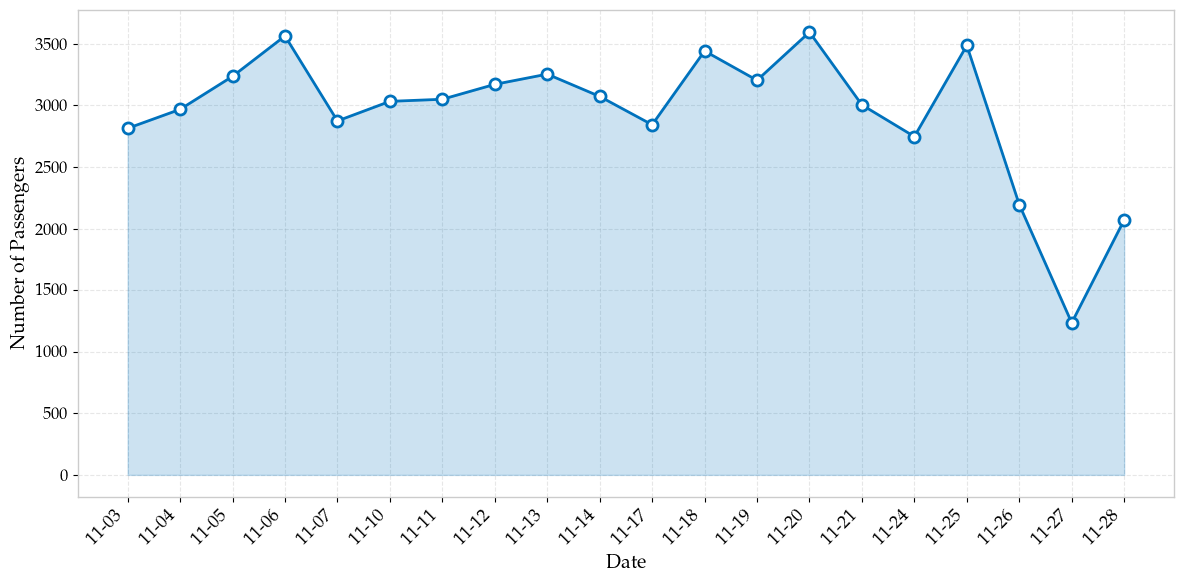

In [7]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ======================================================
# 参数设置（只改这里）
# ======================================================

INPUT_FILES = [
    r"C:\Users\lenovo\Desktop\DQN2\data\yellow_tripdata_2025-11.parquet",
]

CORE_ZONES = [
    237, 161, 236, 186, 162, 230, 142, 239, 163
]

# ======================================================
# 主处理逻辑
# ======================================================

def analyze_daily_trips(input_files, core_zones):
    zone_set = set(core_zones)
    daily_counts = {}

    print("🚕 开始处理 TLC 数据")
    print(f"核心区域: {core_zones}")
    print("时间条件: 工作日 + 17:00–19:00")
    print("=" * 80)

    for file_path in input_files:
        print(f"\n📂 读取文件: {file_path}")
        df = pd.read_parquet(file_path)
        print(f"  原始行数: {len(df):,}")

        # =====================
        # 时间戳处理（毫秒）
        # =====================
        if not np.issubdtype(df["tpep_pickup_datetime"].dtype, np.datetime64):
            df["pickup_dt"] = pd.to_datetime(
                df["tpep_pickup_datetime"], unit="ms"
            )
        else:
            df["pickup_dt"] = df["tpep_pickup_datetime"]

        # =====================
        # 只保留11月
        # =====================
        df = df[df["pickup_dt"].dt.month == 11]
        
        # =====================
        # 工作日 (周一=0, 周日=6)
        # =====================
        df = df[df["pickup_dt"].dt.weekday < 5]

        # =====================
        # 17:00–19:00
        # =====================
        h = df["pickup_dt"].dt.hour
        df = df[(h >= 17) & (h < 19)]

        # =====================
        # 起终点都在核心区域
        # =====================
        df = df[
            df["PULocationID"].isin(zone_set) &
            df["DOLocationID"].isin(zone_set)
        ]

        print(f"  筛选后行数: {len(df):,}")

        if df.empty:
            continue

        # =====================
        # 按天统计乘客数
        # =====================
        df["date"] = df["pickup_dt"].dt.date
        
        for date, group in df.groupby("date"):
            daily_counts[date] = len(group)

    print("\n" + "=" * 80)
    print("📊 11月工作日乘客数统计")
    print("=" * 80)
    
    # 按日期排序
    sorted_dates = sorted(daily_counts.keys())
    sorted_counts = [daily_counts[date] for date in sorted_dates]
    
    # 打印统计表
    print("\n📋 每日乘客数统计:")
    print("-" * 40)
    for date, count in zip(sorted_dates, sorted_counts):
        weekday = pd.Timestamp(date).strftime('%A')
        print(f"{date} ({weekday}): {count:,} 人")
    
    print("\n" + "=" * 80)
    print(f"📈 统计汇总:")
    print(f"   总工作日天数: {len(sorted_dates)}")
    print(f"   总乘客数: {sum(sorted_counts):,} 人")
    print(f"   平均每日: {np.mean(sorted_counts):,.0f} 人")
    print(f"   标准差: {np.std(sorted_counts):,.0f} 人")
    print(f"   最小日: {min(sorted_counts):,} 人")
    print(f"   最大日: {max(sorted_counts):,} 人")
    
    return sorted_dates, sorted_counts


# ======================================================
# 绘制折线图
# ======================================================

def plot_daily_trips(dates, counts):
    # 设置字体
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Palatino"],
        "font.size": 12,
        "axes.labelsize": 14,
        "xtick.labelsize": 13,  # 横坐标日期标注调大
        "ytick.labelsize": 12,
        "lines.linewidth": 2,
    })
    
    fig, ax = plt.subplots(figsize=(12, 6))
    
    # 将日期转换为字符串格式用于显示
    date_labels = [d.strftime('%m-%d') for d in dates]
    x_positions = range(len(dates))
    
    # 绘制折线图
    ax.plot(x_positions, counts, marker='o', markersize=8, 
            color='#0072BD', linewidth=2, markerfacecolor='white', 
            markeredgewidth=2, markeredgecolor='#0072BD')
    
    # 线下标阴影
    ax.fill_between(x_positions, 0, counts, alpha=0.2, color='#0072BD')
    
    # 设置x轴
    ax.set_xticks(x_positions)
    ax.set_xticklabels(date_labels, rotation=45, ha='right')
    
    # 设置y轴
    ax.set_ylabel(r'Number of Passengers', fontsize=14)
    ax.set_xlabel(r'Date', fontsize=14)
    
    # 网格
    ax.grid(True, linestyle='--', alpha=0.3, zorder=0)
    ax.set_axisbelow(True)
    
    # 美化边框
    for spine in ax.spines.values():
        spine.set_edgecolor('#CCCCCC')
        spine.set_linewidth(1)
    
    plt.tight_layout()
    
    # 保存图片
    print("\n💾 图表已保存: daily_passengers_november_2025.png")
    
    plt.show()
    
    return fig, ax


# ======================================================
# 运行
# ======================================================

if __name__ == "__main__":
    # 分析数据
    dates, counts = analyze_daily_trips(INPUT_FILES, CORE_ZONES)
    
    # 绘制图表
    if dates:
        plot_daily_trips(dates, counts)
    else:
        print("❌ 没有找到符合条件的数据")